# EDA

Data rows

In [11]:
import pandas as pd

df = pd.read_csv("deals.csv")

print(df.head())


  deal_id created_date closed_date sales_rep_id    industry         region  \
0  D00001   2023-11-24  2023-12-15       rep_22        SaaS  North America   
1  D00002   2023-01-17  2023-01-27        rep_7        SaaS          India   
2  D00003   2023-10-29  2023-12-10        rep_5  HealthTech           APAC   
3  D00004   2023-07-14  2023-08-02       rep_18     FinTech          India   
4  D00005   2024-02-29  2024-05-26        rep_2  HealthTech           APAC   

  product_type lead_source   deal_stage  deal_amount  sales_cycle_days outcome  
0   Enterprise    Referral    Qualified         4253                21     Won  
1         Core    Referral       Closed         3905                10     Won  
2         Core     Inbound     Proposal        10615                42    Lost  
3         Core     Partner  Negotiation         4817                19     Won  
4         Core    Outbound    Qualified        45203                87    Lost  


Check for data type and null count none in this case

In [12]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   deal_id           5000 non-null   object
 1   created_date      5000 non-null   object
 2   closed_date       5000 non-null   object
 3   sales_rep_id      5000 non-null   object
 4   industry          5000 non-null   object
 5   region            5000 non-null   object
 6   product_type      5000 non-null   object
 7   lead_source       5000 non-null   object
 8   deal_stage        5000 non-null   object
 9   deal_amount       5000 non-null   int64 
 10  sales_cycle_days  5000 non-null   int64 
 11  outcome           5000 non-null   object
dtypes: int64(2), object(10)
memory usage: 468.9+ KB
None


Mean median mode and std for deal amount and sales cycle data Here’s the analysis in

* **Deal sizes are heavily right-skewed** — Mean (26K) is much higher than median (14K), indicating a small number of large deals are affecting the average . Revenue is likely  in top-tier deals.

* **High variability in deal amounts** — Standard deviation (~27K) is almost equal to the mean, meaning revenue forecasting could be volatile and dependent on a few big wins.

* **Sales cycle is relatively symmetric** — Mean (63.7 days) ≈ Median (64 days), suggesting a fairly structured sales process with consistent timelines.

* **Wide spread in sales cycle duration** — 25% of deals take more than 92 days, indicating potential pipeline risk and possible deal stagnation in later stages.

* **Likely segmentation effect** — Larger deals probably have longer sales cycles, implying enterprise deals drive both higher revenue and higher risk; this should be validated via correlation and win-rate analysis by deal size bucket.

In [71]:
print(df.describe())


                     created_date                 closed_date    deal_amount  \
count                        5000                        5000    5000.000000   
mean   2023-08-14 06:10:56.640000  2023-10-17 00:13:32.160000   26286.492800   
min           2023-01-01 00:00:00         2023-01-11 00:00:00    2002.000000   
25%           2023-04-22 00:00:00         2023-06-26 00:00:00    6611.000000   
50%           2023-08-14 00:00:00         2023-10-15 00:00:00   14171.500000   
75%           2023-12-06 00:00:00         2024-02-08 00:00:00   39062.250000   
max           2024-03-26 00:00:00         2024-07-20 00:00:00  100000.000000   
std                           NaN                         NaN   27689.230136   

       sales_cycle_days  
count       5000.000000  
mean          63.751800  
min            7.000000  
25%           35.750000  
50%           64.000000  
75%           92.000000  
max          120.000000  
std           32.731405  


Lost and win balanced around 10 % difference

In [3]:
df["outcome"].value_counts(normalize=True)


,proportion
outcome,
Lost,0.5474
Won,0.4526


lot of outlier and rightly skewed deals data need to be satndiadrized for further ananlaysis

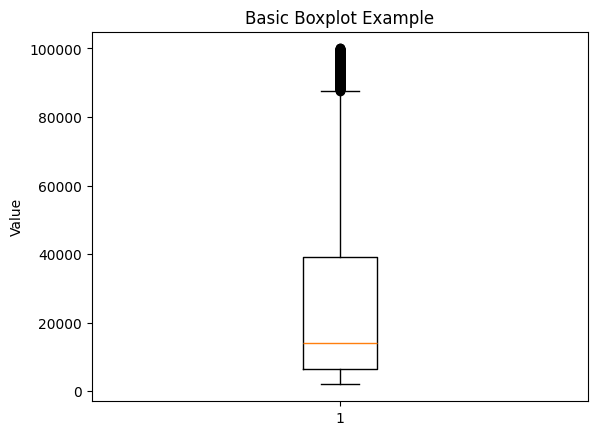

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Create the boxplot
plt.boxplot(df["deal_amount"])

# Add title and labels
plt.title("Basic Boxplot Example")
plt.ylabel("Value")

# Display the plot
plt.show()


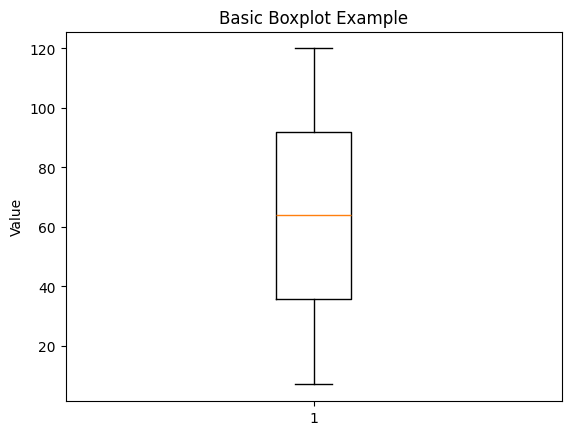

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Create the boxplot
plt.boxplot(df["sales_cycle_days"])

# Add title and labels
plt.title("Basic Boxplot Example")
plt.ylabel("Value")

# Display the plot
plt.show()


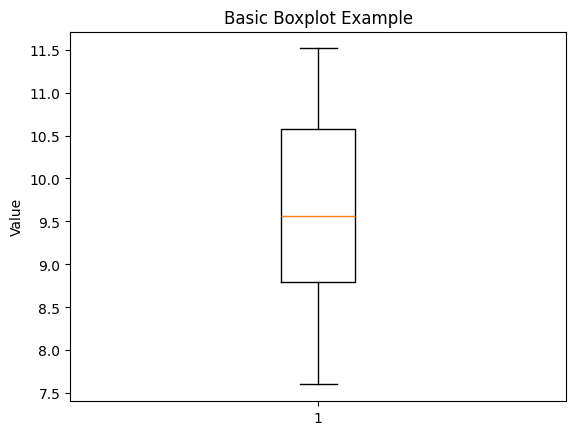

In [74]:
import matplotlib.pyplot as plt
import numpy as np


df["deal_amount_log"] = np.log1p(df["deal_amount"])
# Create the boxplot
plt.boxplot(df["deal_amount_log"])

# Add title and labels
plt.title("Basic Boxplot Example")
plt.ylabel("Value")

# Display the plot
plt.show()


In [19]:
import numpy as np
import pandas as pd # Using pandas for easy quantile calculation

# Sample data with outliers

s = pd.Series(df['deal_amount'])

# Calculate Q1, Q3, and IQR
Q1 = s.quantile(0.25)
Q3 = s.quantile(0.75)
IQR = Q3 - Q1


# Calculate the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


# Find outliers
outliers = s[(s < lower_bound) | (s > upper_bound)]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print("Outliers found:", outliers.values)

Q1: 6611.0, Q3: 39062.25, IQR: 32451.25
Lower Bound: -42065.875, Upper Bound: 87739.125
Outliers found: [ 90575  89616  97304  95392  98561  96011  91364  89066  93664  99320
  98240  94967  98644  95582  95766  90190  87740  88719  96490  88195
  91786  91105  90405  88610  92569  98005  96156  93051  99377  90275
  95771  97983  95385  97616  89489  88506  89824  88945  93801  98918
  89899  99032  96865  88534  90544  98924  89006  96881  98871  93307
  89922  95660  91207  90964  99996  92373  88731  98230  92067  92359
  99970  92964  96595  93778  90728  89119 100000  96662  97704  88616
  88566  93424  87763  91003  91826  97303  92367  98675  91950  95289
  90371  92913  92848  98900  96132  95076  88156  97415  97559  93988
  99443  99034  97460  90837  94379  93142  91016  94381  93737  99691
  92719  91363  95599  94929  95788  95447  98541  97864  93997  99726
  90623  95085  96989  89721  89269  98082  89672  97505  88790  95644
  96269  99362  97612  98331  90015  95060  

Here shows that India closed less value dealsin core products and APAC regio maximum in core such inferences allow to see in which region what product type deals are closed more

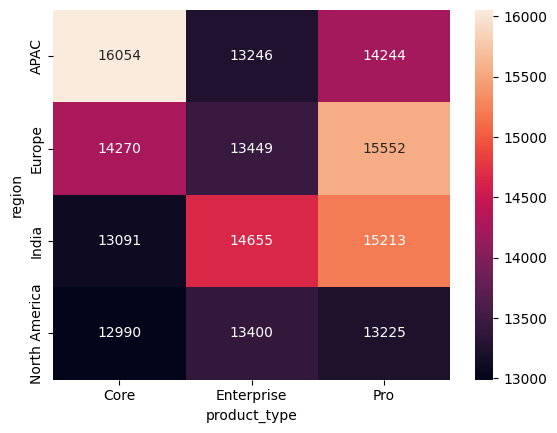

In [76]:
pivot = df.pivot_table(
    values="deal_amount",
    index="region",
    columns="product_type",
    aggfunc="median"
)

sns.heatmap(pivot, annot=True, fmt=".0f")
plt.show()


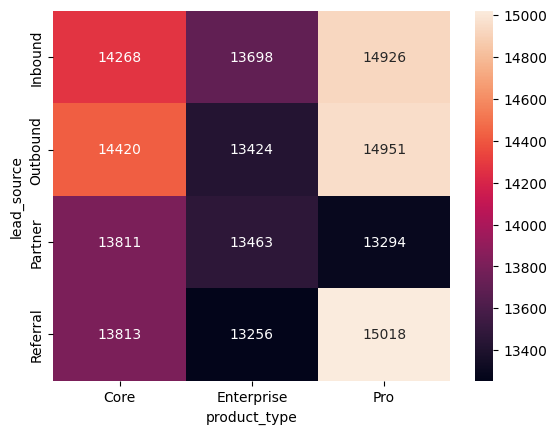

In [92]:
pivot = df.pivot_table(
    values="deal_amount",
    index="lead_source",
    columns="product_type",
    aggfunc="median"
)

sns.heatmap(pivot, annot=True, fmt=".0f")
plt.show()

Shows that deal mount is rightly skewed corrected with low sales cycle seems symmetric

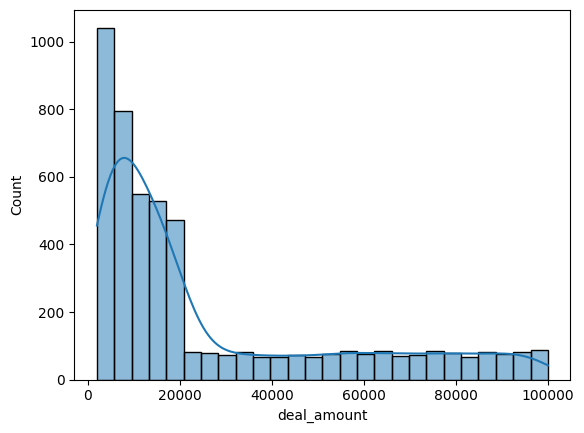

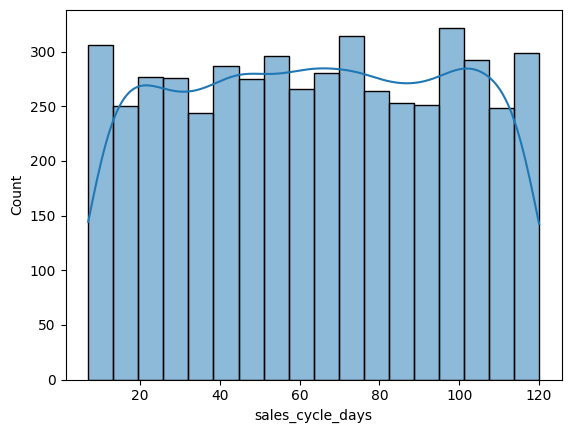

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["deal_amount"], kde=True)
plt.show()

sns.histplot(df["sales_cycle_days"], kde=True)
plt.show()


Now symmetric distribution of deal values after logarithm

<Axes: xlabel='deal_amount_log', ylabel='Count'>

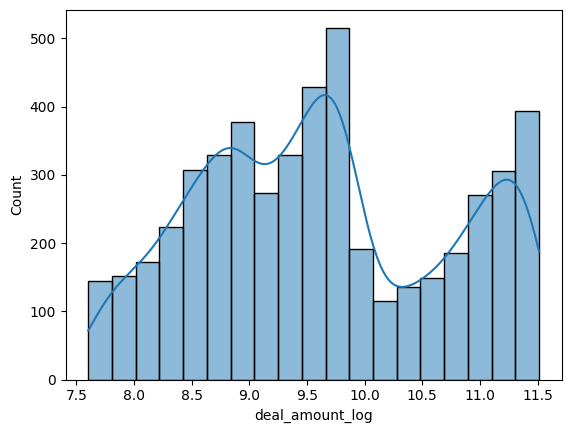

In [20]:

import seaborn as sns
sns.histplot(df["deal_amount_log"], kde=True)


In [21]:
df["deal_amount_log"]

,deal_amount_log
0,8.355615
1,8.270269
2,9.270118
3,8.480114
4,10.718941
...,...
4995,7.858254
4996,9.267665
4997,10.958409
4998,10.834036


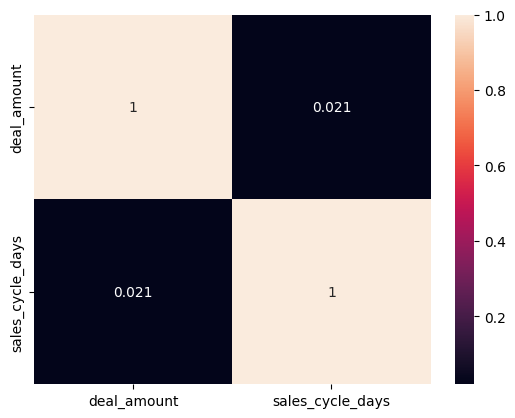

In [5]:
sns.heatmap(df[["deal_amount", "sales_cycle_days"]].corr(), annot=True)
plt.show()


In [6]:
win_rates = pd.crosstab(df["industry"], df["outcome"], normalize="index")
print(win_rates)


outcome         Lost       Won
industry                      
Ecommerce   0.550943  0.449057
EdTech      0.558468  0.441532
FinTech     0.522946  0.477054
HealthTech  0.554455  0.445545
SaaS        0.548452  0.451548


In [27]:
from scipy.stats import f_oneway

groups = [group["deal_amount"] for name, group in df.groupby("region")]
f_stat, p_value = f_oneway(*groups)

print("p-value:", p_value)


p-value: 0.9598490705238063


In [7]:
win_rates = pd.crosstab(df["product_type"], df["outcome"], normalize="index")
print(win_rates)

outcome           Lost       Won
product_type                    
Core          0.544864  0.455136
Enterprise    0.550307  0.449693
Pro           0.547136  0.452864


Almost all represnetaiaitve are performing well on deals, can be improved by more unifromed training

In [8]:
win_rates = pd.crosstab(df["sales_rep_id"], df["outcome"], normalize="index")
print(win_rates)

outcome           Lost       Won
sales_rep_id                    
rep_1         0.545024  0.454976
rep_10        0.575916  0.424084
rep_11        0.535000  0.465000
rep_12        0.516667  0.483333
rep_13        0.558974  0.441026
rep_14        0.560386  0.439614
rep_15        0.554286  0.445714
rep_16        0.529148  0.470852
rep_17        0.554286  0.445714
rep_18        0.591398  0.408602
rep_19        0.520408  0.479592
rep_2         0.538462  0.461538
rep_20        0.530435  0.469565
rep_21        0.490385  0.509615
rep_22        0.599057  0.400943
rep_23        0.554348  0.445652
rep_24        0.551724  0.448276
rep_25        0.546341  0.453659
rep_3         0.527778  0.472222
rep_4         0.541872  0.458128
rep_5         0.542289  0.457711
rep_6         0.572139  0.427861
rep_7         0.583333  0.416667
rep_8         0.518717  0.481283
rep_9         0.553763  0.446237


In [9]:
win_rates = pd.crosstab(df["region"], df["outcome"], normalize="index")
print(win_rates)

outcome            Lost       Won
region                           
APAC           0.550725  0.449275
Europe         0.544201  0.455799
India          0.542768  0.457232
North America  0.552058  0.447942


which categoris have maximum dels meaning

In [37]:
print(df["industry"].value_counts(),\
df["region"].value_counts(),df["sales_rep_id"].value_counts(),\
df["lead_source"].value_counts(),df["product_type"].value_counts())


industry
Ecommerce     1060
HealthTech    1010
SaaS          1001
EdTech         992
FinTech        937
Name: count, dtype: int64 region
India            1286
APAC             1242
North America    1239
Europe           1233
Name: count, dtype: int64 sales_rep_id
rep_20    230
rep_16    223
rep_2     221
rep_3     216
rep_22    212
rep_1     211
rep_21    208
rep_14    207
rep_25    205
rep_7     204
rep_24    203
rep_4     203
rep_5     201
rep_6     201
rep_11    200
rep_19    196
rep_13    195
rep_10    191
rep_8     187
rep_18    186
rep_9     186
rep_23    184
rep_12    180
rep_17    175
rep_15    175
Name: count, dtype: int64 lead_source
Inbound     1262
Referral    1252
Outbound    1246
Partner     1240
Name: count, dtype: int64 product_type
Core          1694
Pro           1676
Enterprise    1630
Name: count, dtype: int64


In [49]:
df.columns.tolist()

['deal_id',
 'created_date',
 'closed_date',
 'sales_rep_id',
 'industry',
 'region',
 'product_type',
 'lead_source',
 'deal_stage',
 'deal_amount',
 'sales_cycle_days',
 'outcome',
 'deal_amount_log']

Values are almost balanced in terms of type


In [66]:
df['Risk_Category'].value_counts()

,count
Risk_Category,
Medium,4759
High,141
Low,100


section 3 win rate ananlsysis

In [106]:
import pandas as pd
import numpy as np

# Sample usage:
# df = pd.read_csv("sales_data.csv")

def win_rate_driver_analysis(df):

    # Convert dates
    df["created_date"] = pd.to_datetime(df["created_date"], dayfirst=True)
    df["closed_date"] = pd.to_datetime(df["closed_date"], dayfirst=True)

    print("--------------------------------------------------")
    print("OVERALL WIN RATE")
    print("--------------------------------------------------")

    total_deals = len(df)
    total_wins = (df["outcome"] == "Won").sum()
    overall_win_rate = total_wins / total_deals if total_deals > 0 else 0

    print("Total Deals:", total_deals)
    print("Total Wins:", total_wins)
    print("Overall Win Rate:", round(overall_win_rate, 4))

    print("\n--------------------------------------------------")
    print("WIN RATE BY DRIVER FACTORS")
    print("--------------------------------------------------")

    driver_columns = [
        "sales_rep_id",
        "industry",
        "region",
        "product_type",
        "lead_source",
        "deal_stage"
    ]

    for col in driver_columns:

        print("\nDriver:", col)

        grouped = df.groupby(col)["outcome"].apply(
            lambda x: (x == "Won").sum() / len(x)
        ).reset_index(name="win_rate")

        grouped["deal_count"] = df.groupby(col)["deal_id"].count().values
        grouped = grouped.sort_values("win_rate")

        print(grouped)

        lowest = grouped.iloc[0]
        highest = grouped.iloc[-1]

        print("Lowest Win Rate Segment:", lowest[col],
              "Win Rate:", round(lowest["win_rate"], 4),
              "Deals:", lowest["deal_count"])

        print("Highest Win Rate Segment:", highest[col],
              "Win Rate:", round(highest["win_rate"], 4),
              "Deals:", highest["deal_count"])

        if lowest["win_rate"] < overall_win_rate * 0.8:
            print("This segment is hurting overall win rate")

        if highest["win_rate"] > overall_win_rate * 1.2:
            print("This segment is significantly improving win rate")

    print("\n--------------------------------------------------")
    print("DEAL SIZE IMPACT")
    print("--------------------------------------------------")

    df["deal_bucket"] = pd.cut(
        df["deal_amount"],
        bins=[0, 5000, 20000, 50000, float("inf")],
        labels=["Small", "Medium", "Large", "Enterprise"]
    )

    size_group = df.groupby("deal_bucket")["outcome"].apply(
        lambda x: (x == "Won").sum() / len(x)
    ).reset_index(name="win_rate")

    print(size_group)

    print("\n--------------------------------------------------")
    print("SALES CYCLE IMPACT")
    print("--------------------------------------------------")

    cycle_analysis = df.groupby("outcome")["sales_cycle_days"].mean().reset_index()
    print("Average Sales Cycle by Outcome")
    print(cycle_analysis)

    won_cycle = cycle_analysis[cycle_analysis["outcome"] == "Won"]["sales_cycle_days"].values
    lost_cycle = cycle_analysis[cycle_analysis["outcome"] == "Lost"]["sales_cycle_days"].values

    if len(won_cycle) > 0 and len(lost_cycle) > 0:
        if won_cycle[0] < lost_cycle[0]:
            print("Shorter sales cycles are associated with higher win rate")
        else:
            print("Longer sales cycles are not negatively impacting win rate")

    print("\n--------------------------------------------------")
    print("TREND ANALYSIS")
    print("--------------------------------------------------")

    df["month"] = df["closed_date"].dt.to_period("M")

    monthly = df.groupby("month")["outcome"].apply(
        lambda x: (x == "Won").sum() / len(x)
    ).reset_index(name="win_rate")

    print(monthly)

    if len(monthly) >= 2:
        if monthly["win_rate"].iloc[-1] > monthly["win_rate"].iloc[-2]:
            print("Win rate is improving in the latest month")
        elif monthly["win_rate"].iloc[-1] < monthly["win_rate"].iloc[-2]:
            print("Win rate is declining in the latest month")
        else:
            print("Win rate is stable")

    print("\n--------------------------------------------------")
    print("FINAL DRIVER SUMMARY")
    print("--------------------------------------------------")

    print("1. Focus on low win rate segments identified above")
    print("2. Replicate strategies from high performing segments")
    print("3. Investigate long sales cycles if losses are higher")
    print("4. Optimize product or region combinations with weak performance")
    print("5. Monitor trend monthly to detect early decline")
win_rate_driver_analysis(df)

--------------------------------------------------
OVERALL WIN RATE
--------------------------------------------------
Total Deals: 5000
Total Wins: 2263
Overall Win Rate: 0.4526

--------------------------------------------------
WIN RATE BY DRIVER FACTORS
--------------------------------------------------

Driver: sales_rep_id
   sales_rep_id  win_rate  deal_count
14       rep_22  0.400943         212
9        rep_18  0.408602         186
22        rep_7  0.416667         204
1        rep_10  0.424084         191
21        rep_6  0.427861         201
5        rep_14  0.439614         207
4        rep_13  0.441026         195
15       rep_23  0.445652         184
8        rep_17  0.445714         175
6        rep_15  0.445714         175
24        rep_9  0.446237         186
16       rep_24  0.448276         203
17       rep_25  0.453659         205
0         rep_1  0.454976         211
20        rep_5  0.457711         201
19        rep_4  0.458128         203
11        rep_2  0.4615

SECTION 4
mini system

In [100]:
# ==========================================================
# SALES INSIGHT & ALERT SYSTEM
# File Logging Only (No print, No logging module)
# ==========================================================

import pandas as pd
import numpy as np
import datetime
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# ==========================================================
# CONFIG
# ==========================================================

DATA_PATH = "deals.csv"
LOG_FILE = "sales_insight_system.log"
ALERT_LOG = "alert_log.csv"
HIGH_RISK_THRESHOLD = 0.50
HIGH_VALUE_THRESHOLD = 50000

# ==========================================================
# FILE LOG FUNCTION
# ==========================================================

def write_log(message):
    print(message)

# ==========================================================
# DATA INGESTION
# ==========================================================

def load_data(path):
    try:
        df = pd.read_csv(path)
        write_log("Data loaded successfully.")
        return df
    except Exception as e:
        write_log(f"ERROR loading data: {e}")
        raise

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

def feature_engineering(df):

    df['created_date'] = pd.to_datetime(df['created_date'], dayfirst=True)
    df['closed_date'] = pd.to_datetime(df['closed_date'], dayfirst=True)

    df['sales_cycle'] = (
        df['closed_date'].fillna(pd.Timestamp.today()) - df['created_date']
    ).dt.days

    df['deal_age'] = (
        pd.Timestamp.today() - df['created_date']
    ).dt.days

    write_log("Feature engineering completed.")
    return df

# ==========================================================
# TRAIN RISK MODEL
# ==========================================================

def train_risk_model(df):

    closed_df = df[df['outcome'].notnull()].copy()

    if closed_df.empty:
        write_log("No closed deals available for training.")
        return None, None, None

    closed_df['target'] = closed_df['outcome'].map({'Won': 1, 'Lost': 0})

    features = [
        'deal_amount',
        'sales_cycle',
        'region',
        'industry',
        'product_type',
        'lead_source',
        'deal_stage'
    ]

    X = closed_df[features]
    y = closed_df['target']

    X = pd.get_dummies(X, drop_first=True)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    write_log(f"Risk model trained. AUC: {round(auc,4)}")

    return model, scaler, X.columns

# ==========================================================
# SCORE OPEN DEALS
# ==========================================================

def score_open_deals(df, model, scaler, feature_columns):

    if model is None:
        write_log("Model not available. Skipping scoring.")
        return pd.DataFrame()

    open_df = df .copy()

    if open_df.empty:
        write_log("No open deals to score.")
        return pd.DataFrame()
    print(open_df)
    features = [
        'deal_amount',
        'sales_cycle_days',
        'region',
        'industry',
        'product_type',
        'lead_source',
        'deal_stage'
    ]

    X_open = open_df[features]
    X_open = pd.get_dummies(X_open, drop_first=True)

    for col in feature_columns:
        if col not in X_open:
            X_open[col] = 0

    X_open = X_open[feature_columns]

    X_scaled = scaler.transform(X_open)

    open_df['loss_probability'] = 1 - model.predict_proba(X_scaled)[:,1]

    write_log(f"Scored {len(open_df)} open deals.")

    return open_df

# ==========================================================
# GENERATE ALERTS
# ==========================================================

def generate_alerts(scored_df):

    alerts = []

    for _, row in scored_df.iterrows():

        if (row['loss_probability'] > HIGH_RISK_THRESHOLD and
            row['deal_amount'] > HIGH_VALUE_THRESHOLD):

            alert = {
                "timestamp": datetime.datetime.now(),
                "deal_id": row['deal_id'],
                "region": row['region'],
                "deal_amount": row['deal_amount'],
                "loss_probability": round(row['loss_probability'], 2),
                "alert_type": "HIGH_RISK_HIGH_VALUE"
            }

            alerts.append(alert)

    alert_df = pd.DataFrame(alerts)

    write_log(f"{len(alert_df)} alerts generated.")

    return alert_df

# ==========================================================
# SAVE ALERTS
# ==========================================================

def save_alerts(alert_df):

    if alert_df.empty:
        write_log("No alerts to save.")
        return

    if os.path.exists(ALERT_LOG):
        existing = pd.read_csv(ALERT_LOG)
        combined = pd.concat([existing, alert_df])
        combined.to_csv(ALERT_LOG, index=False)
    else:
        alert_df.to_csv(ALERT_LOG, index=False)

    write_log("Alerts saved to alert_log.csv.")

# ==========================================================
# PIPELINE SUMMARY
# ==========================================================

def pipeline_summary(scored_df):

    if scored_df.empty:
        write_log("No pipeline summary generated.")
        return

    total_value = scored_df['deal_amount'].sum()
    at_risk_value = scored_df[
        scored_df['loss_probability'] > HIGH_RISK_THRESHOLD
    ]['deal_amount'].sum()

    write_log(f"Total pipeline value: {round(total_value,2)}")
    write_log(f"Revenue at risk: {round(at_risk_value,2)}")

# ==========================================================
# MAIN SYSTEM RUN
# ==========================================================

def run_system():

    write_log("===== Sales Insight System Started =====")

    df = load_data(DATA_PATH)
    df = feature_engineering(df)

    model, scaler, feature_columns = train_risk_model(df)

    scored_df = score_open_deals(df, model, scaler, feature_columns)
    print(scored_df)
    alerts = generate_alerts(scored_df)

    save_alerts(alerts)

    pipeline_summary(scored_df)

    write_log("===== Sales Insight System Completed =====")

# ==========================================================
# ENTRY POINT
# ==========================================================

if __name__ == "__main__":
    run_system()


===== Sales Insight System Started =====
Data loaded successfully.
Feature engineering completed.
Risk model trained. AUC: 0.5033
     deal_id created_date closed_date sales_rep_id    industry         region  \
0     D00001   2023-11-24  2023-12-15       rep_22        SaaS  North America   
1     D00002   2023-01-17  2023-01-27        rep_7        SaaS          India   
2     D00003   2023-10-29  2023-12-10        rep_5  HealthTech           APAC   
3     D00004   2023-07-14  2023-08-02       rep_18     FinTech          India   
4     D00005   2024-02-29  2024-05-26        rep_2  HealthTech           APAC   
...      ...          ...         ...          ...         ...            ...   
4995  D04996   2023-10-17  2023-12-03       rep_13   Ecommerce  North America   
4996  D04997   2023-11-11  2023-12-09       rep_20     FinTech           APAC   
4997  D04998   2023-10-19  2023-10-27       rep_24     FinTech  North America   
4998  D04999   2023-03-12  2023-05-18       rep_21        Sa